# Constraint-Guided Quantum State Preparation: a tutorial
### From *negative conditions* to amplitude amplification and CG-QAOA

**Author:** Alberto Maldonado Romo (QOSF) · companion to *Negation-forced amplitude amplification* and the `negsearch` package.

**The idea in one sentence.** Read every constraint as a forbidden pattern; once all but one of its variables make the pattern impossible to avoid, the last variable is **forced**. Build the quantum state so that forced variables are set deterministically and only the remaining *decisions* are placed in superposition. Algorithms such as Grover/amplitude amplification and QAOA then search a much smaller, structured space instead of the uniform superposition.

**What you will do**
1. See the technique on a small 3-SAT instance and check the exact success-probability formula.
2. Check that *measure-and-flip* dynamic circuits are classical (why the naive approach fails).
3. Run amplitude amplification over the constraint-guided state and compare with Grover.
4. Choose how many conditions to use with ZX-calculus gate costs.
5. Run **CG-QAOA** (constraint-guided QAOA) on an instance derived from QOBLIB and compare it with penalty and Hadfield QAOA.
6. Look at how circuit depth scales with the number of variables, and prepare a run on IBM hardware.

![flowchart](../figures/theory_flowchart.png)

In [1]:
import sys, json, math, random, time
sys.path.insert(0, '..')
import numpy as np, matplotlib.pyplot as plt
from IPython.display import Image, display
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from negsearch.core import (CNF, sample_satisfiable, enumerate_models, success_by_solutions, forcing_plan,
                            amplification_iterations, amplified_success)
from negsearch.circuits import NegForcedSearch, for_simulation, component_circuits
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Negative conditions on a small 3-SAT instance

A clause $(\ell_1\vee\ell_2\vee\ell_3)$ is the negation of the forbidden pattern $\neg\ell_1\wedge\neg\ell_2\wedge\neg\ell_3$. Process the variables in an order $\pi$. When variable $v$ is reached, each clause whose *other* variables are already assigned and all false **forces** the literal of $v$. Otherwise $v$ is a **decision** and receives a Hadamard. The variable qubit is its own coin, so no extra register of random choices is needed.

In [2]:
rng = random.Random(7)
F = sample_satisfiable('3-SAT', 8, rng)
sols = enumerate_models(F)
order = list(range(1, F.n + 1)); rng.shuffle(order)
print(f'{F.n} variables, {F.m} clauses, {len(sols)} solutions; order pi = {order}')
for v, C1, C0 in forcing_plan(F, order):
    print(f'  x{v}: can be forced to 1 by {len(C1)} clause(s), to 0 by {len(C0)} clause(s)')

8 variables, 34 clauses, 6 solutions; order pi = [3, 5, 1, 6, 8, 2, 7, 4]
  x3: can be forced to 1 by 0 clause(s), to 0 by 0 clause(s)
  x5: can be forced to 1 by 0 clause(s), to 0 by 0 clause(s)
  x1: can be forced to 1 by 1 clause(s), to 0 by 1 clause(s)
  x6: can be forced to 1 by 0 clause(s), to 0 by 1 clause(s)
  x8: can be forced to 1 by 1 clause(s), to 0 by 0 clause(s)
  x2: can be forced to 1 by 5 clause(s), to 0 by 3 clause(s)
  x7: can be forced to 1 by 5 clause(s), to 0 by 3 clause(s)
  x4: can be forced to 1 by 11 clause(s), to 0 by 3 clause(s)


### Exact success probability (Lemma 3 of the paper)

Forced values never contradict a solution, so every solution $a$ is reached by exactly one branch, with probability $2^{-D_\pi(a)}$, where $D_\pi(a)$ is the number of decisions on that branch:
$$p_\pi=\sum_{a\in\text{Sol}}2^{-D_\pi(a)} .$$
Below we compare the formula with a simulation of the circuit (matrix-product-state sampling), and with the uniform superposition used by Grover ($M/2^n$).

In [3]:
circ = NegForcedSearch(F, order).amplified(0)          # A|0> followed by measurement
S = 20000
cnt = AerSimulator(method='matrix_product_state').run(for_simulation(circ), shots=S, seed_simulator=1).result().get_counts()
p_circuit = sum(c for s, c in cnt.items() if F.check_bitstring(s)) / S
p_formula, D = success_by_solutions(F, order, sols)
print(f'circuit qubits = {circ.num_qubits} (variables + reusable ancillas), simulated with MPS ({S} shots)')
print(f'P(solution): circuit = {p_circuit:.4f} +- {math.sqrt(p_formula*(1-p_formula)/S):.4f} | Lemma 3 = {p_formula:.4f} | uniform (Grover) = {len(sols)/2**F.n:.4f}')
print(f'decisions along each solution: {D} (out of {F.n} variables)')

circuit qubits = 79 (variables + reusable ancillas), simulated with MPS (20000 shots)
P(solution): circuit = 0.1254 +- 0.0023 | Lemma 3 = 0.1250 | uniform (Grover) = 0.0234
decisions along each solution: [6, 6, 6, 5, 6, 5] (out of 8 variables)


## 2. Why the naive dynamic-circuit approach is classical

A tempting alternative is to measure constraint ancillas mid-circuit and flip violated variables with classical feed-forward. If the checks are computational-basis measurements and the corrections are permutations (X, CNOT, Toffoli), the circuit is **exactly** a classical randomized algorithm (Lemma 1 of the paper). Here we compare a measure-and-flip 2-colouring of a 10-vertex path, simulated with the stabilizer method, against the same rule run in plain Python.

In [4]:
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr
def measure_and_flip(n, edges, iters):
    v = QuantumRegister(n, 'v'); e = QuantumRegister(len(edges), 'e'); ce = ClassicalRegister(len(edges)); cv = ClassicalRegister(n)
    qc = QuantumCircuit(v, e, ce, cv); qc.h(v)
    for _ in range(iters):
        for k, (i, j) in enumerate(edges): qc.cx(v[i], e[k]); qc.cx(v[j], e[k])
        qc.measure(e, ce)
        for k, (i, j) in enumerate(edges):
            with qc.if_test(expr.logic_not(ce[k])): qc.x(v[i])
        qc.reset(e)
    qc.measure(v, cv); return qc
n, E = 10, [(i, i + 1) for i in range(9)]
def classical(iters, trials=200000):
    x = np.random.default_rng(0).integers(0, 2, (trials, n), dtype=np.int8)
    for _ in range(iters): x[:, :-1] ^= (x[:, :-1] == x[:, 1:]).astype(np.int8)
    return np.all(x[:, :-1] != x[:, 1:], axis=1).mean()
stab = AerSimulator(method='stabilizer')
for it in (2, 5, 10):
    cnt = stab.run(transpile(measure_and_flip(n, E, it), stab), shots=20000, seed_simulator=1).result().get_counts()
    q = sum(c for s, c in cnt.items() if all(s.split()[0][n-1-i] != s.split()[0][n-1-j] for i, j in E)) / 20000
    print(f'iterations={it:2d}: quantum circuit {q:.4f} | classical rule {classical(it):.4f}')

iterations= 2: quantum circuit 0.0092 | classical rule 0.0077


iterations= 5: quantum circuit 0.0627 | classical rule 0.0632


iterations=10: quantum circuit 1.0000 | classical rule 1.0000


## 3. Amplitude amplification over the constraint-guided state

With preparation $A$ and success probability $p$, amplitude amplification needs about $\frac{\pi}{4}/\sqrt{p}$ rounds of $A\,S_0\,A^\dagger\,O$, versus $\frac{\pi}{4}\sqrt{2^n/M}$ Grover rounds from the uniform state. We simulate the **full circuit** (oracle, $A$, $A^\dagger$, reflection) with the matrix-product-state simulator and compare with theory. *(The Grover baseline needs more rounds and more entanglement: about 10 minutes on a laptop CPU.)*

In [5]:
pG = len(sols) / 2**F.n
kN, kG = amplification_iterations(p_formula), amplification_iterations(pG)
mps = AerSimulator(method='matrix_product_state')
for label, base, p, k in (('negation-forced', False, p_formula, kN), ('Grover (uniform)', True, pG, kG)):
    circ = NegForcedSearch(F, order, baseline=base).amplified(k)
    t0 = time.time(); cnt = mps.run(for_simulation(circ), shots=1000, seed_simulator=3).result().get_counts()
    ok = sum(c for s, c in cnt.items() if F.check_bitstring(s)) / 1000
    print(f'{label:17s} rounds={k:2d}  success: simulated={ok:.3f}  theory={amplified_success(p, k):.3f}   ({circ.num_qubits} qubits, {time.time()-t0:.0f} s)')

negation-forced   rounds= 2  success: simulated=0.943  theory=0.945   (79 qubits, 1 s)


Grover (uniform)  rounds= 5  success: simulated=0.992  theory=0.986   (79 qubits, 681 s)


## 4. How many conditions? ZX-guided selection

Checking more negative conditions raises $p$ (fewer rounds) but makes $A$ more expensive. We cap the number of conditions per variable at $K$, compute $p_K$ exactly, simplify each circuit with ZX-calculus (PyZX) and evaluate the expected total $T$-count
$$\mathcal T(K)=\tfrac{\pi}{4}\,p_K^{-1/2}\,\big(2\,T(A_K)+T(O)+T(S_0)\big).$$

In [6]:
from negsearch.zxtools import to_clifford_t, zx_reduce, counts_qiskit
rng2 = random.Random(3); F6 = sample_satisfiable('3-SAT', 6, rng2); s6 = enumerate_models(F6)
o6 = list(range(1, 7)); rng2.shuffle(o6)
def zxT(qc):
    ct = to_clifford_t(qc); c2, _ = zx_reduce(ct); return counts_qiskit(ct)['T'], c2.tcount()
comps = component_circuits(F6, o6, None); TO = zxT(comps['O'])[1]; TS = zxT(comps['S0'])[1]
rows = []
for K in (0, 1, 2, None):
    if K == 0: p, TA0, TA = len(s6) / 64, 0, 0
    else:
        p, _ = success_by_solutions(F6, o6, s6, K); TA0, TA = zxT(component_circuits(F6, o6, K)['A'])
    rows.append((K, p, TA0, TA, math.pi / 4 / math.sqrt(p) * (2 * TA + TO + TS)))
    print(f"K={'inf' if K is None else K}: p={p:.3f}  T(A) {TA0}->{TA} after ZX   expected total T = {rows[-1][-1]:.0f}")
print('best K:', min(rows, key=lambda r: r[-1])[0], '(K=0 is Grover)')

K=0: p=0.062  T(A) 0->0 after ZX   expected total T = 2388


K=1: p=0.062  T(A) 180->68 after ZX   expected total T = 2815


K=2: p=0.141  T(A) 348->142 after ZX   expected total T = 2187


K=inf: p=0.156  T(A) 894->362 after ZX   expected total T = 2949
best K: 2 (K=0 is Grover)


## 5. CG-QAOA on a QOBLIB instance

**Problem:** maximum independent set (QOBLIB class 07). Every constraint is "not both endpoints", so a variable can only be forced to 0 and there are **no conflicts**. The constraint-guided state $A_q|0\rangle$ (a coin of bias $q$ for each undecided vertex) is supported **exactly** on the independent sets. CG-QAOA uses it as the initial state and in a Grover mixer $A_q e^{-i\beta|0\rangle\langle0|}A_q^\dagger$, so it never leaves the feasible space and needs no penalty terms.

`karate-sub18` is an 18-vertex induced subgraph of the QOBLIB `karate` graph where min-degree greedy is not optimal (`../instances/qoblib/`, CC BY 4.0).

In [7]:
from scipy.optimize import minimize
from negsearch.qaoa_mis import read_gph, MIS, prep_biased
n, E = read_gph('../instances/qoblib/karate-sub18.gph'); g = MIS(n, E)
order_mis = sorted(range(n), key=lambda v: (len(g.N[v]), v))
psi = prep_biased(g, order_mis, 0.7); pr = np.abs(psi)**2
print(f'optimum={g.opt}; P(infeasible) under A_q = {pr[~g.feas].sum():.1e}; independent sets reached: {(pr[g.feas]>0).sum()} of {g.feas.sum()}')

rng = np.random.default_rng(0); sig = lambda z: 1 / (1 + np.exp(-z))
def best_of(f, dim, starts=3):
    return min((minimize(f, rng.uniform(0, np.pi, dim), method='COBYLA', options={'maxiter': 250}) for _ in range(starts)), key=lambda r: r.fun)
t0 = time.time()
lam = 2.0; Cpen = -g.size + lam * g.viol
r_pen = best_of(lambda x: float((np.abs(g.penalty_state(x, lam))**2 * Cpen).sum()), 2)
r_had = best_of(lambda x: -float((np.abs(g.hadfield_state(x))**2 * g.size).sum()), 2)
fcg = lambda x: -float((np.abs(g.gm_state(x[:2], prep_biased(g, order_mis, sig(x[2]))))**2 * g.size).sum())
r_cg = min((minimize(fcg, np.r_[rng.uniform(0, np.pi, 2), 1.0], method='COBYLA', options={'maxiter': 250}) for _ in range(3)), key=lambda r: r.fun)
q = sig(r_cg.x[2])
res = {'Penalty QAOA (QUBO)': g.metrics(g.penalty_state(r_pen.x, lam)), 'Hadfield QAOA': g.metrics(g.hadfield_state(r_had.x)),
       f'CG-QAOA (q={q:.2f})': g.metrics(g.gm_state(r_cg.x[:2], prep_biased(g, order_mis, q))),
       f'classical sampling of A_q (q={q:.2f})': g.metrics(prep_biased(g, order_mis, q))}
print(f'p = 1, optimised in {time.time()-t0:.0f} s')
print(f"{'method':36s} {'P(feasible)':>11s} {'approx. ratio':>13s} {'P(optimum)':>10s}")
for k, m in res.items(): print(f"{k:36s} {m['p_feas']:11.3f} {m['ratio']:13.3f} {m['p_opt']:10.4f}")

optimum=10; P(infeasible) under A_q = 0.0e+00; independent sets reached: 2771 of 2771


p = 1, optimised in 63 s
method                               P(feasible) approx. ratio P(optimum)
Penalty QAOA (QUBO)                        0.416         0.178     0.0001
Hadfield QAOA                              1.000         0.495     0.0008
CG-QAOA (q=0.97)                           1.000         0.904     0.0649
classical sampling of A_q (q=0.97)         1.000         0.883     0.0212


**Reading the table honestly.** One CG-QAOA layer applies $A$, $A^\dagger$ and $A$ again (3 preparations). Three classical samples from $A_q$ reach the optimum with probability $1-(1-P)^3$, which roughly matches CG-QAOA at $p=1$. The quantum gain grows with depth (about 1.3–2.3× at $p=2$ in our study) and, above all, with amplitude amplification, which needs quadratically fewer preparations. The precomputed study over 8 QOBLIB instances is in `../results/cg_qaoa_sub.json` and `../results/cg_qaoa_full.json`:

In [8]:
R = {**json.load(open('../results/cg_qaoa_sub.json')), **json.load(open('../results/cg_qaoa_full.json'))}
print(f"{'instance':32s} p | ratio: penalty  Hadfield  CG  | P(opt): penalty   Hadfield   CG")
for name, r in R.items():
    for p in (1, 2):
        if f'p{p}' in r:
            d = r[f'p{p}']
            print(f"{name:32s} {p} |       {d['penalty']['ratio']:.2f}     {d['hadfield']['ratio']:.2f}   {d['cg_qvar']['ratio']:.2f} |   {d['penalty']['p_opt']:.4f}    {d['hadfield']['p_opt']:.4f}   {d['cg_qvar']['p_opt']:.3f}")
print('\namplification vs classical sampling (q = 0.5):')
for name, r in R.items():
    a = next(x for x in r['amplification'] if x['q'] == 0.5)
    print(f"  {name:32s} classical {a['classical_samples']:7.0f} samples  vs  {a['quantum_prep_calls']:6.1f} quantum preparations  ({a['classical_samples']/a['quantum_prep_calls']:.0f}x)")

instance                         p | ratio: penalty  Hadfield  CG  | P(opt): penalty   Hadfield   CG
karate-sub18                     1 |       0.20     0.50   0.90 |   0.0000    0.0008   0.065
karate-sub18                     2 |       0.30     0.80   0.92 |   0.0002    0.0000   0.212
chesapeake-sub18                 1 |       0.16     0.56   0.89 |   0.0001    0.0000   0.088
chesapeake-sub18                 2 |       0.14     0.78   0.91 |   0.0002    0.0000   0.256
frb50-23-3-sub18                 1 |       0.13     0.34   0.90 |   0.0001    0.0010   0.114
frb50-23-3-sub18                 2 |       0.18     1.00   0.92 |   0.0000    1.0000   0.285
C125-9-sub18                     1 |       0.15     0.46   0.91 |   0.0000    0.0000   0.049
C125-9-sub18                     2 |       0.30     0.73   0.92 |   0.0000    0.0244   0.195
hamming6-4-sub18                 1 |       0.15     0.32   0.87 |   0.0001    0.0001   0.285
hamming6-4-sub18                 2 |       0.23     0.90   0.9

## 6. Circuit depth versus number of variables

The left and middle panels show the depth of one layer on MIS subgraphs of the QOBLIB `karate` graph, with all-to-all connectivity and routed on `ibm_fez` (heavy-hex). The right panel shows 3-SAT. Ancilla-assisted synthesis makes the CG-QAOA layer roughly linear. Penalty QAOA has the cheapest layer, but it spends most samples on infeasible states.

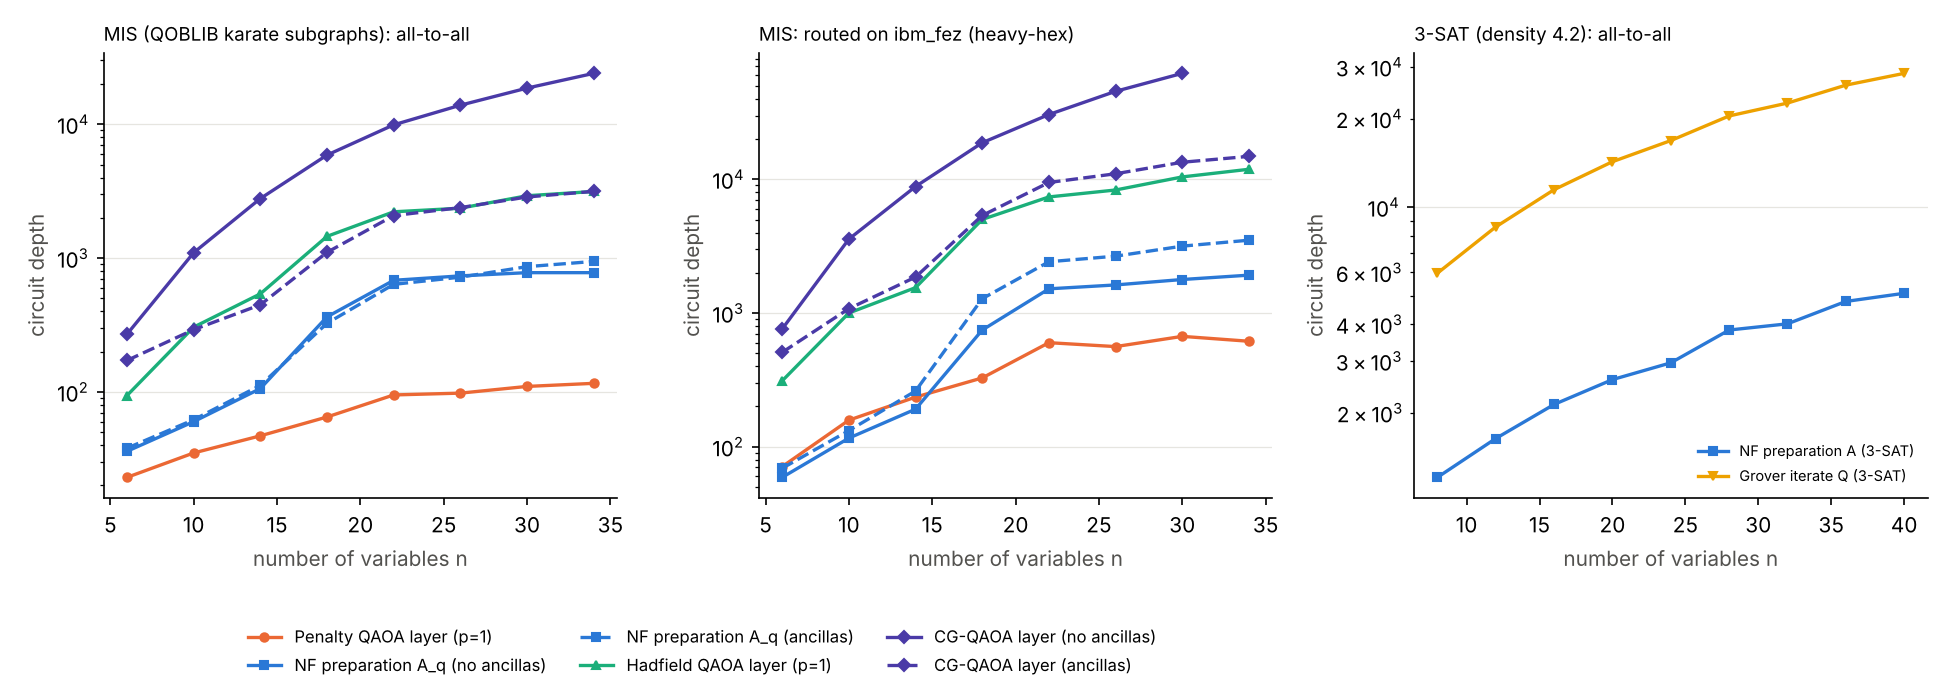

In [9]:
display(Image('../figures/fig_depth_scaling.png'))

What matters for a search is the **total** depth to reach a solution: rounds × depth per round. A constraint-guided round is ~1.6× deeper than a Grover round, but needs exponentially fewer rounds:

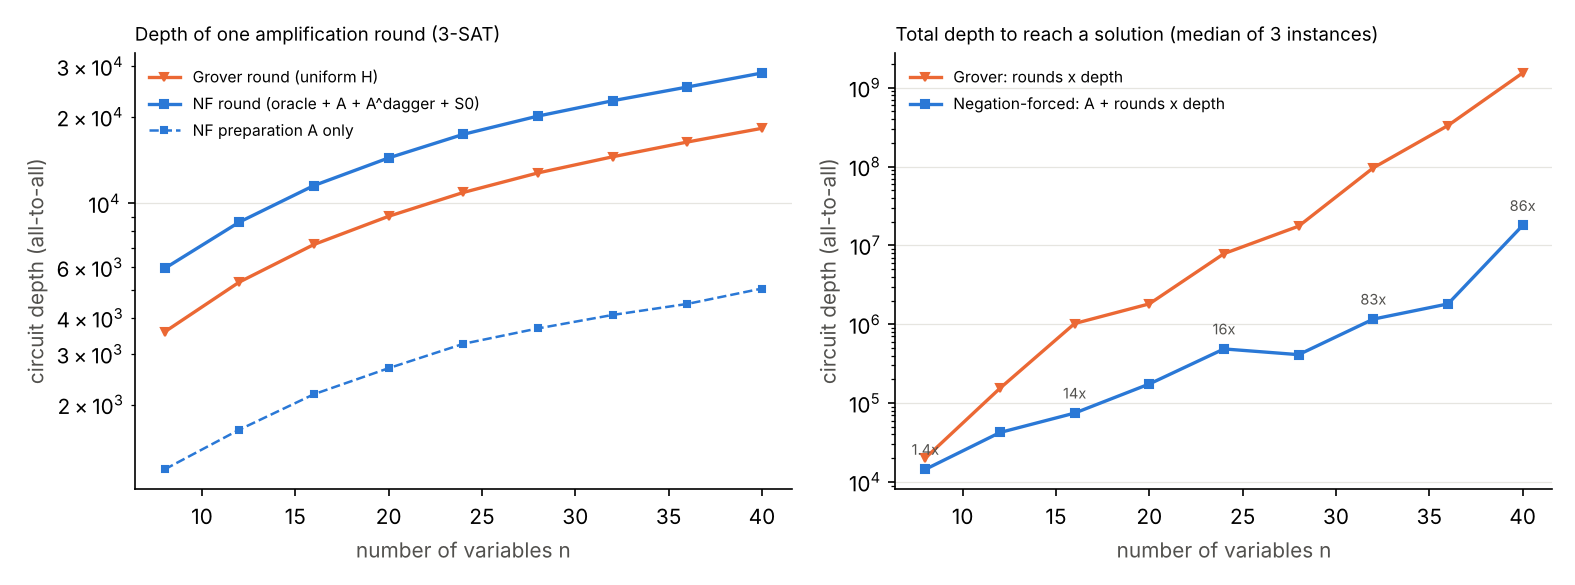

n= 8: rounds Grover=     5.6  NF=   2.2 | total depth Grover=2.01e+04  NF=1.45e+04  (1.4x)
n=12: rounds Grover=    29.0  NF=   4.6 | total depth Grover=1.54e+05  NF=4.24e+04  (3.6x)
n=16: rounds Grover=   142.2  NF=   6.3 | total depth Grover=1.02e+06  NF=7.47e+04  (13.7x)
n=20: rounds Grover=   201.1  NF=  12.2 | total depth Grover=1.81e+06  NF=1.75e+05  (10.4x)
n=24: rounds Grover=   719.3  NF=  27.4 | total depth Grover=7.86e+06  NF=4.87e+05  (16.2x)
n=28: rounds Grover=  1371.7  NF=  20.2 | total depth Grover=1.75e+07  NF=4.12e+05  (42.6x)
n=32: rounds Grover=  6645.0  NF=  51.1 | total depth Grover=9.63e+07  NF=1.16e+06  (82.9x)
n=36: rounds Grover= 20286.7  NF=  69.6 | total depth Grover=3.31e+08  NF=1.81e+06  (182.9x)
n=40: rounds Grover= 84053.2  NF= 640.2 | total depth Grover=1.54e+09  NF=1.79e+07  (85.8x)


In [10]:
display(Image('../figures/fig_depth_to_solution.png'))
for r in json.load(open('../results/depth_to_solution_3sat.json')):
    print(f"n={r['n']:2d}: rounds Grover={r['rounds_Grover']:8.1f}  NF={r['rounds_NF']:6.1f} | total depth Grover={r['total_depth_Grover']:.2e}  NF={r['total_depth_NF']:.2e}  ({r['total_depth_Grover']/r['total_depth_NF']:.1f}x)")

## 7. Running on IBM Quantum

On today's hardware the realistic experiment is the constraint-guided preparation alone, compared with depth-1 penalty QAOA (the approach of the IBM QAOA submission to QOBLIB). The full CG-QAOA layer needs thousands of two-qubit gates. Set `RUN_HARDWARE = True` and point `API_KEY_FILE` to a JSON file `{"apikey": "..."}`.

In [11]:
from negsearch.qaoa_circuits import prep_circuit, penalty_qaoa, cg_qaoa
from qiskit_ibm_runtime.fake_provider import FakeFez
def degeneracy_order(N, n):
    rem = set(range(n)); seq = []
    while rem:
        v = min(rem, key=lambda u: (len(N[u] & rem), u)); seq.append(v); rem.remove(v)
    return seq[::-1]
circs = {'A_q (degeneracy order)': prep_circuit(n, g.N, degeneracy_order(g.N, n), 0.95),
         'penalty QAOA p=1': penalty_qaoa(n, E, lam, [r_pen.x[0]], [r_pen.x[1]]),
         'CG-QAOA p=1': cg_qaoa(n, g.N, order_mis, q, [r_cg.x[0]], [r_cg.x[1]])}
circs['A_q (degeneracy order)'].measure_all()
for k, c in circs.items():
    t = transpile(c, FakeFez(), optimization_level=3, seed_transpiler=1)
    print(f"{k:24s} CZ on ibm_fez = {t.count_ops().get('cz', 0):5d}   depth = {t.depth()}")

RUN_HARDWARE = False
API_KEY_FILE = 'apikey_personal.json'
if RUN_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
    service = QiskitRuntimeService(channel='ibm_cloud', token=json.load(open(API_KEY_FILE))['apikey'])
    backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n)
    keys = ['A_q (degeneracy order)', 'penalty QAOA p=1']
    sampler = Sampler(mode=backend); sampler.options.dynamical_decoupling.enable = True; sampler.options.twirling.enable_gates = True
    job = sampler.run([transpile(circs[k], backend, optimization_level=3) for k in keys], shots=8000); print('job_id:', job.job_id())
    for k, pub in zip(keys, job.result()):
        cnt = pub.data.meas.get_counts(); S = sum(cnt.values())
        feas = sum(c for s, c in cnt.items() if all(not (int(s[::-1][u]) and int(s[::-1][v])) for u, v in E))
        print(f'{k}: feasible fraction = {feas/S:.3f}')
else:
    print('hardware run disabled')

A_q (degeneracy order)   CZ on ibm_fez =   341   depth = 745
penalty QAOA p=1         CZ on ibm_fez =   171   depth = 331


CG-QAOA p=1              CZ on ibm_fez =  7183   depth = 17453
hardware run disabled


## 8. Summary

| | What the technique gives | Limits |
|---|---|---|
| **Construction** | A general compiler from constraints to an in-place state where every variable is its own coin | The exponent for full forcing equals amplified PPZ (known) |
| **Exact accounting** | $p=\sum_a 2^{-D(a)}$ before running anything; pick the order and $K$ | Requires enumerating or sampling solutions for the exact value |
| **Feasibility** | Packing / independence constraints: support = feasible set exactly (CG-QAOA never leaves it) | Equalities and permutations create dead ends; that is the next research step |
| **Search cost** | Total depth to solution 1.4×–183× below Grover for 3-SAT, $n=8$–$40$ (median of 3 instances); quadratically fewer preparations than classical sampling | No advantage over classical CDCL / MIS solvers at these sizes |
| **Hardware** | The preparation alone fits current devices; CG-QAOA layers need fault tolerance or ZX-optimised compilation | Noise on today's devices removes most of the ideal gain |